In [11]:
import matplotlib.pyplot as plt
from matplotlib.cm import viridis
from pathlib import Path
from typing import Any
import json
import os
import numpy as np
from scipy.ndimage import gaussian_filter1d
import pandas as pd
from scipy.stats import shapiro, levene, rankdata, linregress
from statsmodels.formula.api import ols
import statsmodels.api as sm

import helper

In [12]:
class JSONLogger:
    def __init__(self, filepath: str):
        self.filepath = Path(filepath)
        self.filepath.parent.mkdir(parents=True, exist_ok=True)

    def append(self, results: Any) -> None:
        with self.filepath.open("a") as f:
            f.write(json.dumps(results) + "\n")

    def read(self) -> list:
        results = []
        with open(self.filepath) as f:
            results = [json.loads(line) for line in f]
        return results

In [13]:
#MUTATIONAL ROBUTNESS

root="~/scratch/detailed_save/"
exp_type = "variable"
candidate_idx = 299

#Get data from variable experiments
data = []
num_reps = 15
rules=[22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]
root="~/CA_GRN_results/detailed_save/"
exp_type = "variable"
candidate_idx = -1
vdata=[]
for rule in rules:
    filename = os.path.expanduser(f"{root}/noise_results/testing/stats_{rule}_{exp_type}_{candidate_idx}_pheno_data.csv")
    df = pd.read_csv(filename)
    vdata.append(df["Pheno_dists1"].to_list())
    for i in range(num_reps):
        data.append({'CA': str(rule), 'Env': "vari", 'Val': df["Pheno_dists1"].to_list()[i]})

#Static experiments, S1
exp_type = "static"
sdata=[]
for rule in rules:
    filename = os.path.expanduser(f"{root}/noise_results/testing/stats_{rule}_{exp_type}_{candidate_idx}_pheno_data.csv")
    df = pd.read_csv(filename)
    sdata.append(df["Pheno_dists1"].to_list())
    for i in range(num_reps):
        data.append({'CA': str(rule), 'Env': "stat", 'Val': df["Pheno_dists1"].to_list()[i]})

#Static experiments, S2
root="~/scratch/testing_noisy" #due to later experimentation
s2data=[]
for rule in rules:
    filename = os.path.expanduser(f"{root}/stats_{rule}_{exp_type}2_{candidate_idx}_pheno_data.csv")
    df = pd.read_csv(filename)
    s2data.append(df["Pheno_dists1"].to_list())
    for i in range(num_reps):
        data.append({'CA': str(rule), 'Env': "stat", 'Val': df["Pheno_dists1"].to_list()[i]})

df = pd.DataFrame(data)

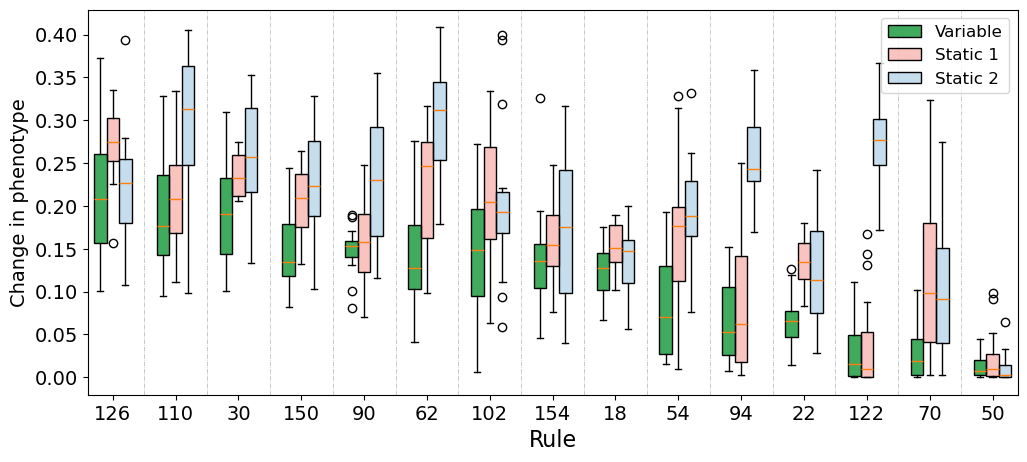

In [14]:
ixs = np.argsort(np.array(vdata).mean(axis=1))[::-1]

v1 = np.array(vdata)
s1 = np.array(sdata)
s2 = np.array(s2data)

M = 22*22 #number of cells x number of developmental steps
v1 /= M
s1 /= M
s2 /= M

# Create the plot
plt.figure(figsize=(12, 5))
scale = 2.5

positions1 = np.arange(1, len(v1) + 1) * scale - 0.5  # Shift left
positions2 = np.arange(1, len(s1) + 1) * scale  # Centered
positions3 = np.arange(1, len(s2) + 1) * scale + 0.5  # Shift right

cmaps=["Greens", "Reds", "Blues"]
x=160

box1=plt.boxplot(v1[ixs].T, positions=positions1, patch_artist=True)
for patch in box1['boxes']:
    color_map = plt.get_cmap(cmaps[0])
    patch.set_facecolor(color_map(x))
box2=plt.boxplot(s1[ixs].T, positions=positions2, patch_artist=True)
for patch in box2['boxes']:
    color_map = plt.get_cmap(cmaps[1])
    rgba = color_map(x)
    patch.set_facecolor((rgba[0], rgba[1], rgba[2], 0.3))

box3=plt.boxplot(s2[ixs].T, positions=positions3, patch_artist=True)
for patch in box3['boxes']:
    color_map = plt.get_cmap(cmaps[2])
    rgba = color_map(x)
    patch.set_facecolor((rgba[0], rgba[1], rgba[2], 0.3))

N = 14
for i in range(N):
    plt.axvline(positions3[i] + 0.75, linestyle="-.", alpha=0.3, c="black",lw=0.5)

plt.legend([box1["boxes"][0], box2["boxes"][0], box3["boxes"][0]], ["Variable", "Static 1", "Static 2"], loc="upper right",prop={'size': 12})
plt.xticks(ticks=np.arange(1, len(vdata) + 1)*scale, labels=np.array(rules)[ixs])
# plt.ylabel("|Original - Mutated phenotypes|", fontsize=14)
plt.ylabel("Change in phenotype", fontsize=14)
plt.xlabel("Rule", fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.savefig('figs/fig4A.pdf', format='pdf', bbox_inches="tight")


In [5]:
print("Shapiro-Wilk Test for Normality:")
for i, group in enumerate(vdata, start=1):
    stat, p = shapiro(group)
    print(f"Group {i}: W={stat:.3f}, p={p:.3f}")
    if p > 0.05:
        print(f"  Group {i} follows a normal distribution (p > 0.05).")
    else:
        print(f"  Group {i} does not follow a normal distribution (p ≤ 0.05).")
        break

print("\nLevene's Test for Homogeneity of Variances:")
stat, p = levene(*vdata)
print(f"Levene's statistic={stat:.3f}, p={p:.3f}")
if p > 0.05:
    print("Variances are homogeneous (p > 0.05).")
else:
    print("Variances are not homogeneous (p ≤ 0.05).")


Shapiro-Wilk Test for Normality:
Group 1: W=0.949, p=0.509
  Group 1 follows a normal distribution (p > 0.05).
Group 2: W=0.975, p=0.927
  Group 2 follows a normal distribution (p > 0.05).
Group 3: W=0.851, p=0.018
  Group 3 does not follow a normal distribution (p ≤ 0.05).

Levene's Test for Homogeneity of Variances:
Levene's statistic=3.315, p=0.000
Variances are not homogeneous (p ≤ 0.05).


In [6]:
# Perform ANOVA on rank the data
df['rank'] = rankdata(df['Val'])
model = ols('rank ~ C(CA) + C(Env) + C(CA):C(Env)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# Perform ANOVA (parametric!)
formula = 'Val ~ C(CA) + C(Env) + C(CA):C(Env)'
model = ols(formula, df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                    sum_sq     df           F        PR(>F)
C(CA)         9.811884e+06   14.0   36.196598  7.719399e-72
C(Env)        2.633437e+06    1.0  136.008609  1.188270e-28
C(CA):C(Env)  6.948545e+05   14.0    2.563358  1.351225e-03
Residual      1.248867e+07  645.0         NaN           NaN
                     sum_sq     df           F        PR(>F)
C(CA)         574419.721764   14.0   35.384223  1.755750e-70
C(Env)        148740.880677    1.0  128.274019  3.014792e-27
C(CA):C(Env)   41416.856321   14.0    2.551276  1.427925e-03
Residual      747913.479736  645.0         NaN           NaN


In [ ]:
#Mutations like in the EA

dir_path = Path(f"~/CA_GRN_results/detailed_save/variable/").expanduser()
seeds = [69904,149796]
grn_size = 22
num_cells = 22
dev_steps = 22
geneid = 1
nclones=2500
mut_rate = 0.1
mut_size = 0.5
num_genes_mutate = int((grn_size + 2) * grn_size * nclones * mut_rate)

candidate_idx=299

rules = [54, 122]

all_f1s = []
all_f2s = []
for rule in rules:
    files = [file for file in dir_path.iterdir() if file.is_file() and file.name.startswith(f"stats_300_{rule}") and file.name.endswith("_best_grn.txt")]
    f1s=[]
    f2s=[]
    for filename in files:

        grns = np.loadtxt(filename)
        num_grns = int(grns.shape[0] / (grn_size + 2) / grn_size)
        grns = grns.reshape(num_grns, grn_size + 2, grn_size)

        candidate = grns[candidate_idx]
        clones = np.tile(candidate, (nclones, 1, 1))

        #Mutation
        mutations = np.random.randn(num_genes_mutate) * mut_size
        x, y, z = clones.shape
        xs = np.random.choice(x, size=num_genes_mutate)
        ys = np.random.choice(y, size=num_genes_mutate)
        zs = np.random.choice(z, size=num_genes_mutate)
        clones[xs, ys, zs] = clones[xs, ys, zs] + mutations

        clones[0] = candidate
        target1, phenos1, fitnesses1 = helper.get_pop_TPF(
            clones, len(clones), num_cells, grn_size, dev_steps, geneid, rule, seeds[0], seeds[0]
        )
        f1s.append(fitnesses1)
        target2, phenos2, fitnesses2 = helper.get_pop_TPF(
            clones, len(clones), num_cells, grn_size, dev_steps, geneid, rule, seeds[1], seeds[1]
        )
        f2s.append(fitnesses2)
    all_f1s.append(f1s)
    all_f2s.append(f2s)

#data = np.array([all_f1s[0],all_f2s[0],all_f1s[1],all_f2s[1]])
#np.save("mut_effect_distribution.npy", data) 

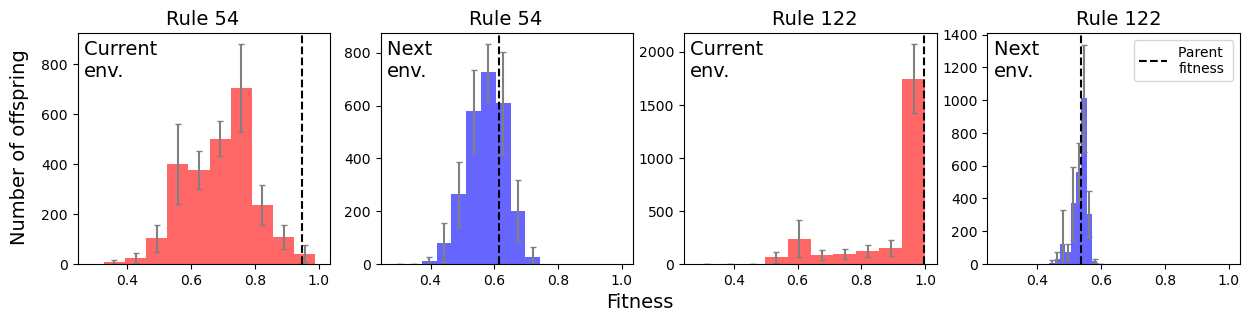

In [10]:
arr = np.load("mut_effect_distribution.npy")


fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 3),sharex=True, sharey=False)
axes = axes.flatten()

colors = ["red", "blue","red", "blue"]
labels1 = ["Rule 54", "Rule 54", "Rule 122", "Rule 122"]
labels2 = ["Current \nenv.", "Next \nenv.", "Current \nenv.", "Next \nenv."]
for idx, i in enumerate(arr):

    _, bins = np.histogram(i.flatten(), density=False)

    all_counts = []
    ori_fs = []
    for f in i: #go through replicate runs
        ori_fs.append(f[0])
        counts, _ = np.histogram(f, bins=bins, density=False)
        all_counts.append(counts)

    all_counts = np.array(all_counts) 

    # Average and variability across replicates
    mean_counts = all_counts.mean(axis=0)
    std_counts = all_counts.std(axis=0) 
    ci95 = 1.96 * std_counts / np.sqrt(all_counts.shape[0])

    # Plot as bar histogram
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    width = (bins[1] - bins[0])

    axes[idx].bar(bin_centers, mean_counts, width=width, align="center", color=colors[idx], edgecolor = None, alpha=0.6,
        yerr=ci95, error_kw={"capsize": 2.0, "ecolor": "grey"})
    
    axes[idx].text(0.35, 1.1, f'{labels1[idx]}', transform=axes[idx].transAxes,
            fontsize=14, va='top', ha='left')
    axes[idx].text(0.025, 0.97, f'{labels2[idx]}', transform=axes[idx].transAxes,
            fontsize=14, va='top', ha='left')

    if idx == 3:
        axes[idx].axvline(sum(ori_fs)/len(ori_fs), linestyle="--", color="black", label = "Parent \nfitness")
    else:
        axes[idx].axvline(sum(ori_fs)/len(ori_fs), linestyle="--", color="black")
    #axes[idx].plot(sum(ori_fs)/len(ori_fs), 0, marker="*", color="yellow", markersize=18, markeredgecolor="black", markeredgewidth=1,zorder=5)
    axes[idx].set_ylim(0,None)

fig.supxlabel('Fitness', fontsize = 14, y=-0.05)
fig.supylabel('Number of offspring', fontsize = 14, x=0.08)
plt.legend()
#plt.tight_layout()
plt.savefig('figs/fig3A.pdf', format='pdf', bbox_inches="tight")

Rule:  54 , Current env


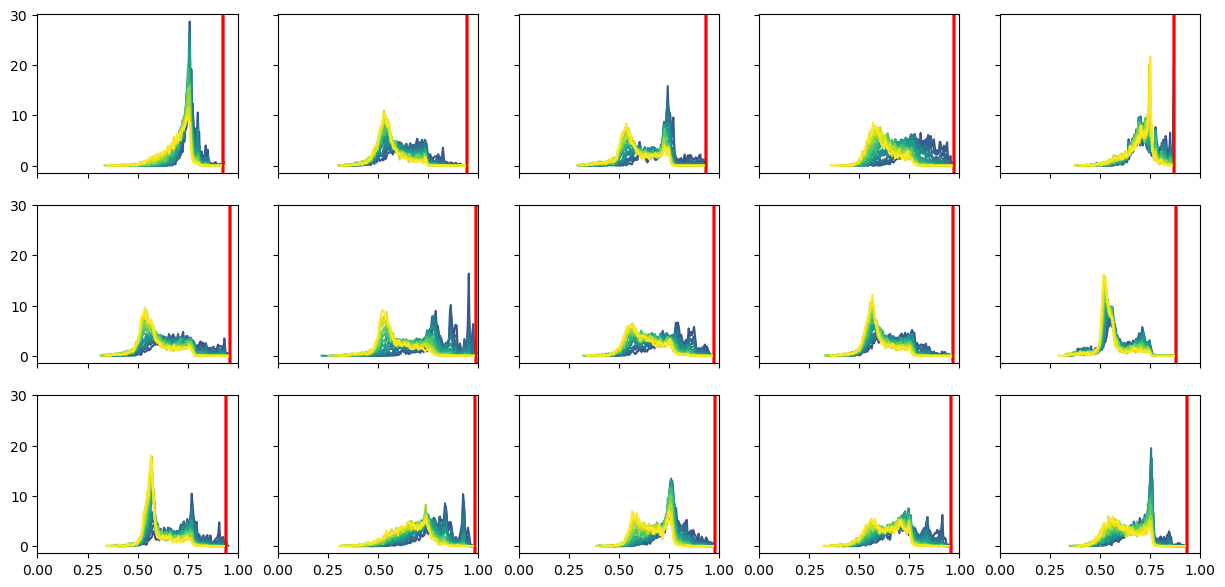

In [7]:
#Distribution of mutation effects on fitness --------------------------------------------

root="~/CA_GRN_results/detailed_save/"
M=0.3
N=20
sigma = 1000  # Smoothing parameter, adjust as needed

exp_type = "variable"
rule = 54
candidate_idx=299

filename = os.path.expanduser(f"{root}/noise_results/stats_{rule}_{exp_type}_{candidate_idx}_env1_noise_data.jsonl")
log = JSONLogger(filename)
all_data = log.read()

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 7),sharex=True, sharey=True)
axes = axes.flatten()

c=0
for idx, exp in enumerate(all_data):
    max_fit = 0
    if "69904" in Path(exp["file"]).name:
        data = exp["data"]
        for i, (fitnesses, noise) in enumerate(zip(data, np.linspace(0, M, N))):
            if noise == 0:
                ori = fitnesses[0]
            counts, bins = np.histogram(fitnesses, bins=100, density=True)
            if i >4:
                axes[c].plot(
                    bins[1:],
                    gaussian_filter1d(counts, sigma=0.1),
                    color=viridis(i / (N - 1)),
                    label=f"{noise:.3f}",
                )
            axes[c].axvline(ori, color="red")
            if max(fitnesses) > max_fit:
                max_fit = max(fitnesses)
        c+=1
        
plt.xlim(0,1)
print("Rule: ", rule, ", Current env")
plt.show()

Rule:  54 , Next env


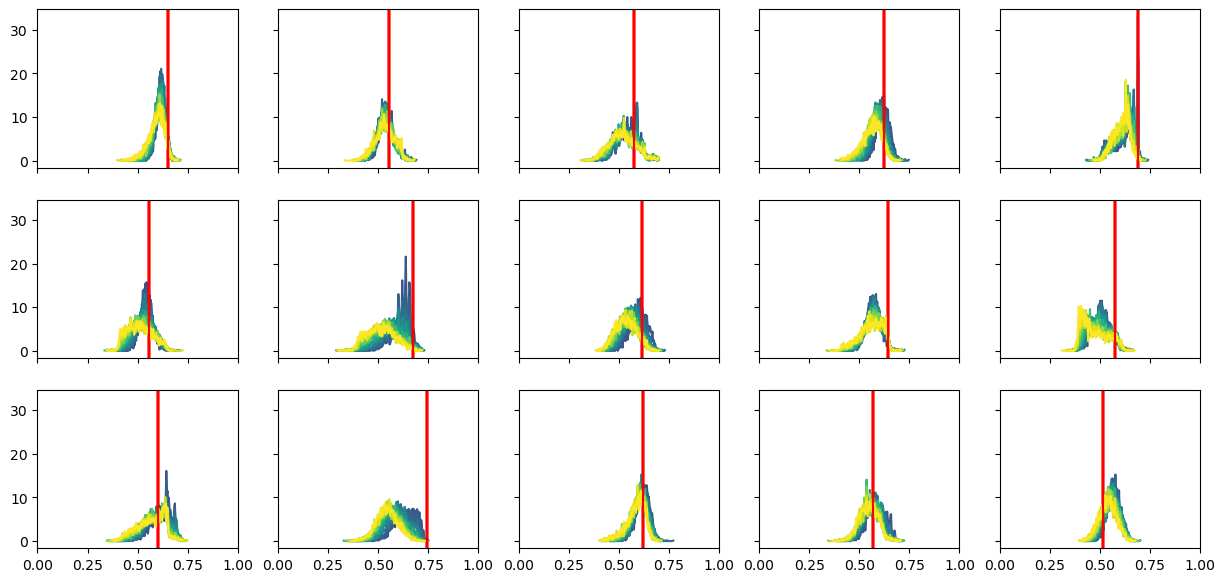

In [8]:
exp_type = "variable"
rule = 54
candidate_idx=299

filename = os.path.expanduser(f"{root}/noise_results/stats_{rule}_{exp_type}_{candidate_idx}_env2_noise_data.jsonl")
log = JSONLogger(filename)
all_data = log.read()

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 7),sharex=True, sharey=True)
axes = axes.flatten()

c=0
for idx, exp in enumerate(all_data):
    max_fit = 0
    if "69904" in Path(exp["file"]).name:
        data = exp["data"]
        for i, (fitnesses, noise) in enumerate(zip(data, np.linspace(0, M, N))):
            if noise == 0:
                ori = fitnesses[0]
            counts, bins = np.histogram(fitnesses, bins=100, density=True)
            if i >4:
                axes[c].plot(
                    bins[1:],
                    gaussian_filter1d(counts, sigma=0.1),
                    color=viridis(i / (N - 1)),
                    label=f"{noise:.3f}",
                )
            axes[c].axvline(ori, color="red")
            if max(fitnesses) > max_fit:
                max_fit = max(fitnesses)
        c+=1

plt.xlim(0,1)
print("Rule: ", rule, ", Next env")
plt.show()

Rule:  122 , Current env


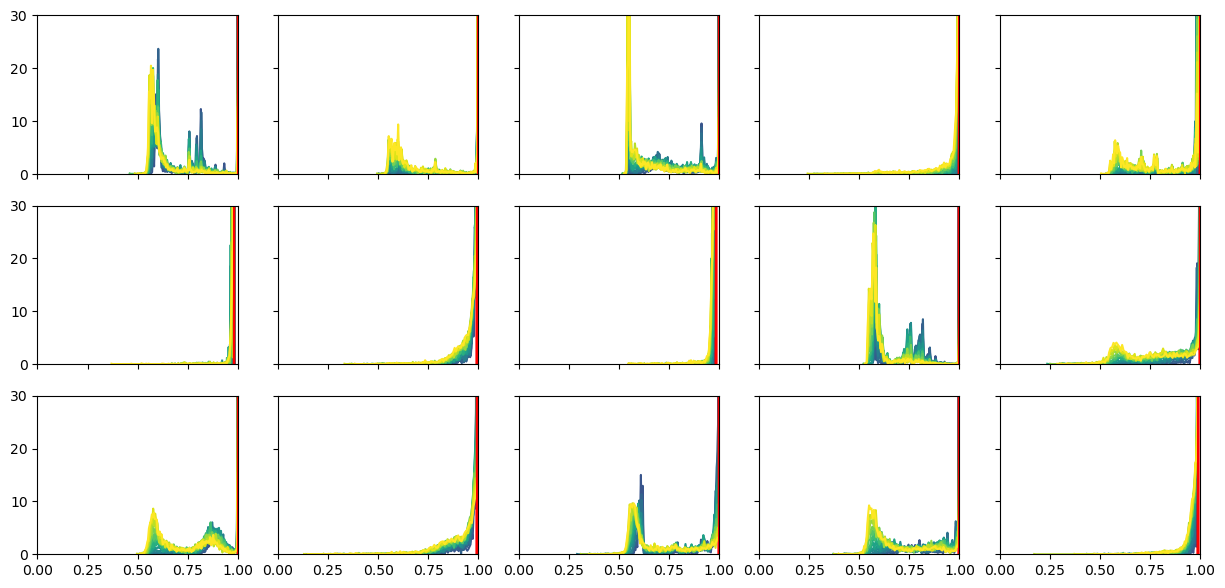

In [9]:
exp_type = "variable"
rule = 122
candidate_idx=299

filename = os.path.expanduser(f"{root}/noise_results/stats_{rule}_{exp_type}_{candidate_idx}_env1_noise_data.jsonl")
log = JSONLogger(filename)
all_data = log.read()

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 7),sharex=True, sharey=True)
axes = axes.flatten()

c=0
for idx, exp in enumerate(all_data):
    max_fit = 0
    if "69904" in Path(exp["file"]).name:
        data = exp["data"]
        for i, (fitnesses, noise) in enumerate(zip(data, np.linspace(0, M, N))):
            if noise == 0:
                ori = fitnesses[0]
            counts, bins = np.histogram(fitnesses, bins=100, density=True)
            if i >4:
                axes[c].plot(
                    bins[1:],
                    gaussian_filter1d(counts, sigma=0.1),
                    color=viridis(i / (N - 1)),
                    label=f"{noise:.3f}",
                )
            axes[c].axvline(ori, color="red")
            if max(fitnesses) > max_fit:
                max_fit = max(fitnesses)
        c+=1

plt.ylim(0,30)
plt.xlim(0,1)
print("Rule: ", rule, ", Current env")
plt.show()

Rule:  122 , Next env


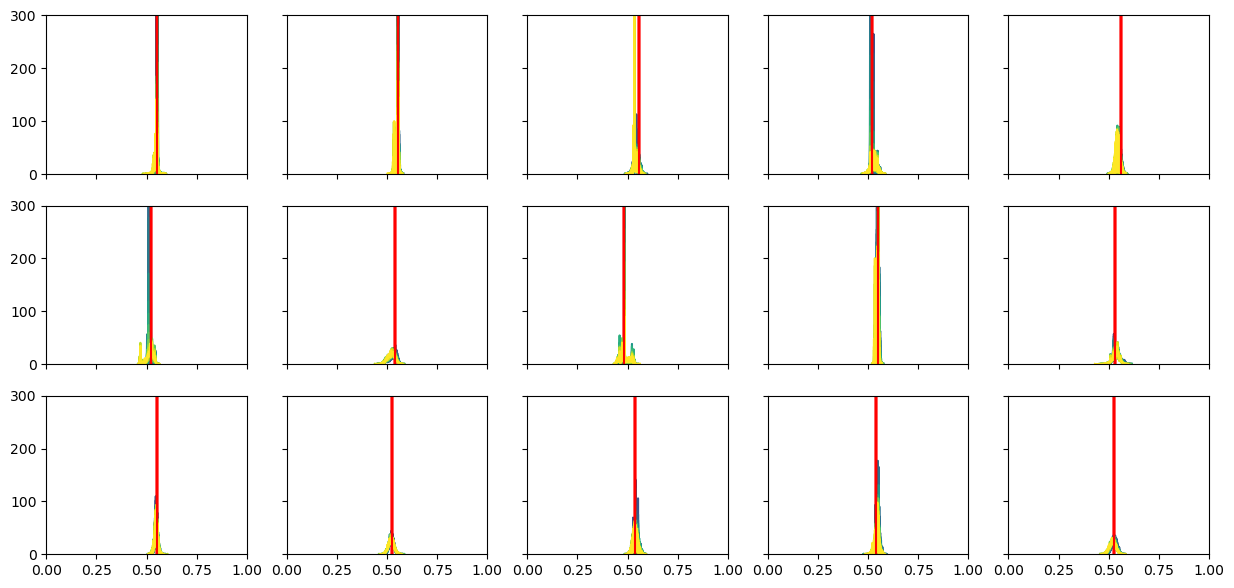

In [10]:
exp_type = "variable"
rule = 122
candidate_idx=299

filename = os.path.expanduser(f"{root}/noise_results/stats_{rule}_{exp_type}_{candidate_idx}_env2_noise_data.jsonl")
log = JSONLogger(filename)
all_data = log.read()

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 7),sharex=True, sharey=True)
axes = axes.flatten()

c=0
for idx, exp in enumerate(all_data):
    max_fit = 0
    if "69904" in Path(exp["file"]).name:
        data = exp["data"]
        for i, (fitnesses, noise) in enumerate(zip(data, np.linspace(0, M, N))):
            if noise == 0:
                ori = fitnesses[0]
            counts, bins = np.histogram(fitnesses, bins=100, density=True)
            if i >4:
                axes[c].plot(
                    bins[1:],
                    gaussian_filter1d(counts, sigma=0.1),
                    color=viridis(i / (N - 1)),
                    label=f"{noise:.3f}",
                )
            axes[c].axvline(ori, color="red")
            if max(fitnesses) > max_fit:
                max_fit = max(fitnesses)
        c+=1

plt.xlim(0,1)
plt.ylim(0,300)
print("Rule: ", rule, ", Next env")
plt.show()

In [13]:
#Effect of evolution in the first season -----------------------------------

root="~/CA_GRN_results/detailed_save/"
exp_type = 'variable'
candidate_idx = 299 #at the end of the first season
M=0.3
N=20
rss=[]
ass=[]
rules = [22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]

for r in rules:
    filename = os.path.expanduser(f"{root}/noise_results/stats_{r}_{exp_type}_{candidate_idx}_env1_unsorted_noise_data.jsonl")
    log = JSONLogger(filename)
    all_data1 = log.read()

    filename = os.path.expanduser(f"{root}/noise_results/stats_{r}_{exp_type}_{candidate_idx}_env2_unsorted_noise_data.jsonl")
    log = JSONLogger(filename)
    all_data2 = log.read()

    rs=[] #r-value of correlation
    ss=[] #variation in next season
    ps=[] #p-values of correlation
    for i in range(15): #for each replicate experiment
        data1 = all_data1[i]["data"]
        data2 = all_data2[i]["data"]
        for idx, noise in enumerate(np.linspace(0, M, N)):
            if idx == 10:
                x = data1[idx]
                y = data2[idx]
                slope, intercept, r_value, p_value, std_err = linregress(x, y)
                x_fit = np.linspace(min(x), max(x), 100)
                y_fit = slope * x_fit + intercept
                
                ps.append(p_value)
                rs.append(r_value)
                ss.append(np.array(y).std())
                
    rss.append(sum(rs)/len(rs)) #average r-value across replicates
    ass.append(sum(ss)/len(ss)) #average variation in next season across replicates
    

In [14]:
#y-axis values from main scatterplots (figure 2)
maxys = [-0.00720094649143832, -0.008174637860203005, -0.022848330602733613, 0.013015457849643086, -0.06102947563834127, -0.005306464337946903, 0.08152268596762813, -0.027037971490074475, -0.0016690028230015308, -0.001235639733614291, 0.046506426564111636, -0.0015349670195471399, -0.004574131473320531, -0.0038457864212471105, 0.045161091155387245]

r-squared:  0.08923521677461176
p-value:  0.27946764446877065


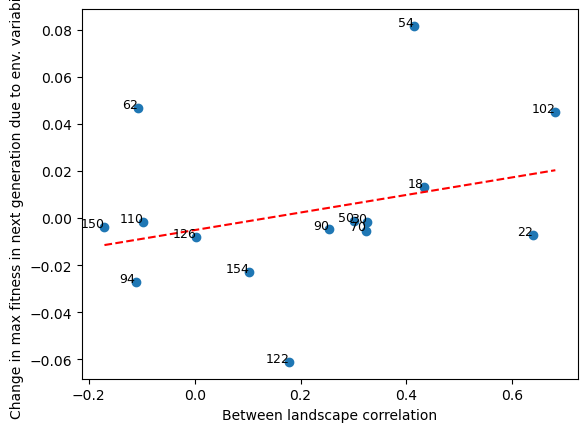

In [15]:
x=list(np.array(rss))
y=list(np.array(maxys))

plt.scatter(x,y)

slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_fit = np.linspace(min(x), max(x), 100)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color='red', linestyle='--', label=f'Fit: y = {slope:.2f}x + {intercept:.2f}')

for i, label in enumerate(np.array(rules)):
    plt.text(x[i], y[i], label, fontsize=9, ha='right')

plt.xlabel("Between landscape correlation")
plt.ylabel("Change in max fitness in next generation due to env. variability ")

print("r-squared: ", r_value*r_value)
print("p-value: ", p_value)


r-squared:  0.5015359639277013
p-value:  0.006749084554112716


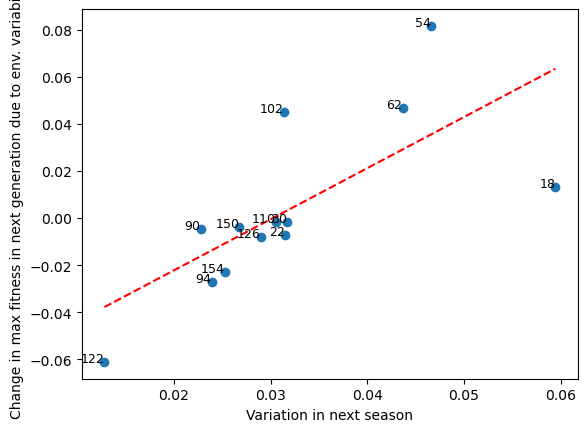

In [16]:
reach_max = [50,70]
rules_mask = []
for i, r in enumerate(rules):
    if r not in reach_max:
        rules_mask.append(i)

x=list(np.array(ass)[rules_mask])
y=list(np.array(maxys)[rules_mask])

plt.scatter(x,y)

slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_fit = np.linspace(min(x), max(x), 100)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color='red', linestyle='--', label=f'Fit: y = {slope:.2f}x + {intercept:.2f}')

for i, label in enumerate(np.array(rules)[rules_mask]):
    plt.text(x[i], y[i], label, fontsize=9, ha='right')

plt.xlabel("Variation in next season")
plt.ylabel("Change in max fitness in next generation due to env. variability ")

print("r-squared: ", r_value*r_value)
print("p-value: ", p_value)